In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline
sns.set_style("whitegrid")

In [3]:
# to import the dataset
df = pd.read_csv("HDB_resale_price_2025.csv")

In [4]:
# to make a raw copy for analysis
df_raw = df.copy()
df_raw.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [6]:
# to check for missing values
100 * df_raw.isnull().sum()/len(df_raw)

month                  0.0
town                   0.0
flat_type              0.0
block                  0.0
street_name            0.0
storey_range           0.0
floor_area_sqm         0.0
flat_model             0.0
lease_commence_date    0.0
remaining_lease        0.0
resale_price           0.0
dtype: float64

In [7]:
df_raw.info()
df_raw.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226376 entries, 0 to 226375
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                226376 non-null  object 
 1   town                 226376 non-null  object 
 2   flat_type            226376 non-null  object 
 3   block                226376 non-null  object 
 4   street_name          226376 non-null  object 
 5   storey_range         226376 non-null  object 
 6   floor_area_sqm       226376 non-null  float64
 7   flat_model           226376 non-null  object 
 8   lease_commence_date  226376 non-null  int64  
 9   remaining_lease      226376 non-null  object 
 10  resale_price         226376 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.0+ MB


(226376, 11)

In [8]:
# to check for any duplicated values
duplicates = df_raw[df_raw.duplicated()]

In [9]:
duplicates # there are 311 rows of duplicates

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
243,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
305,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
510,2017-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0
591,2017-01,JURONG WEST,4 ROOM,337A,TAH CHING RD,19 TO 21,92.0,Model A,2010,92 years 03 months,470000.0
672,2017-01,PASIR RIS,4 ROOM,753,PASIR RIS ST 71,01 TO 03,105.0,Model A,1996,78 years 10 months,368000.0
...,...,...,...,...,...,...,...,...,...,...,...
214458,2025-04,SENGKANG,4 ROOM,457B,SENGKANG WEST RD,13 TO 15,93.0,Model A,2020,94 years 06 months,685000.0
215696,2025-09,TAMPINES,3 ROOM,601B,TAMPINES AVE 9,07 TO 09,68.0,Model A,2020,93 years 06 months,630000.0
220974,2025-05,YISHUN,4 ROOM,426B,YISHUN AVE 11,10 TO 12,92.0,Model A,2015,88 years 11 months,595000.0
222536,2026-01,BUKIT BATOK,3 ROOM,340,BT BATOK ST 34,07 TO 09,73.0,Model A,1987,60 years 06 months,440000.0


In [10]:
# to remove all duplicated values
df_raw.drop_duplicates(inplace=True)

In [11]:
df_raw.shape # 311 duplicated values have been removed

(226065, 11)

C:\Users\miche\AppData\Local\Temp\ipykernel_13872\3215016329.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  count_plot = sns.countplot(data=df, x='flat_type', palette='Set2')


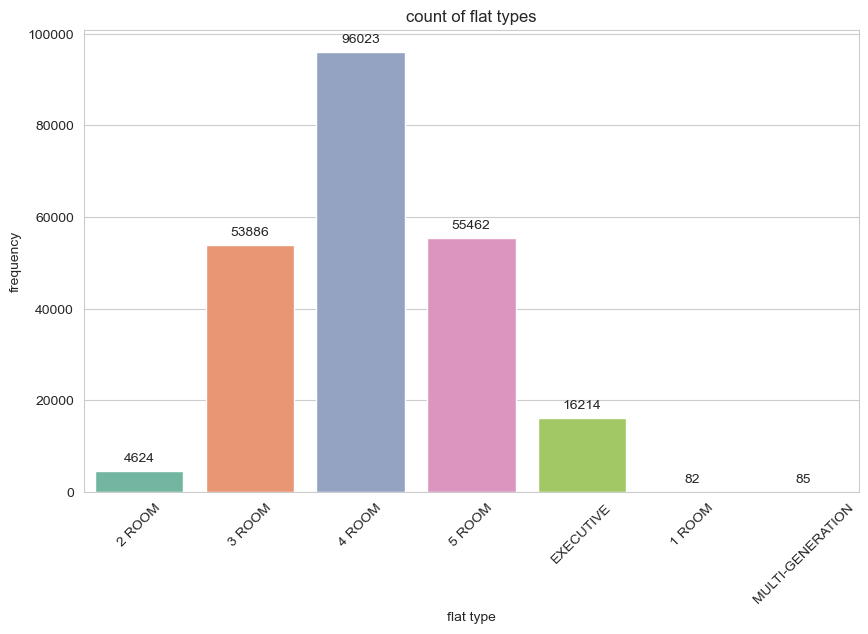

In [16]:
# Exploratory data analysis phase
# bar chart with annotations
plt.figure(figsize=(10,6), dpi=100)
count_plot = sns.countplot(data=df, x='flat_type', palette='Set2')
plt.title('count of flat types')
plt.xlabel('flat type')
plt.ylabel('frequency')
plt.xticks(rotation=45)

# Annotate the bars with frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() /2., p.get_height()),
                        ha = 'center', va='center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

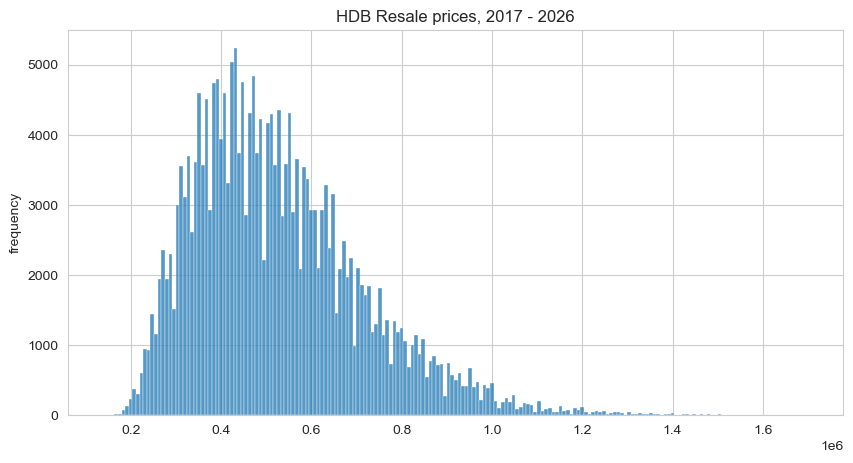

In [19]:
# Distribution of resale flat prices
plt.figure(figsize=(10,5), dpi=100)
sns.histplot(data=df_raw, x='resale_price')
plt.title("HDB Resale prices, 2017 - 2026")
plt.ylabel("frequency")
plt.xlabel("")
plt.show()

In [20]:
# to convert 'month' column into date time format
df_raw['month'] = pd.to_datetime(df_raw['month'])

In [24]:
# extract month and year from datetime column
df_raw['Year'] = df_raw['month'].dt.year
df_raw['Month'] = df_raw['month'].dt.month

In [27]:
# to remove redundant column
df_raw = df_raw.drop('month', axis=1)

In [28]:
df_raw.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,Year,Month
0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017,1
1,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017,1
2,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017,1
3,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017,1
4,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017,1


In [29]:
# to convert 'remaining_lease' column into a float variable
df_raw['remaining_lease'] = (pd.to_numeric(df_raw['remaining_lease'].str.extractall(r'(\d+)')[0])
                         .unstack().div([1,12]).sum(axis= 1)
                         .round(2))

In [30]:
df_raw['remaining_lease']

0         61.33
1         60.58
2         62.42
3         62.08
4         62.42
          ...  
226371    65.42
226372    58.33
226373    60.75
226374    60.67
226375    60.83
Name: remaining_lease, Length: 226065, dtype: float64

C:\Users\miche\AppData\Local\Temp\ipykernel_13872\4193788472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df_raw, x='Year' ,y='resale_price', palette='Set1')


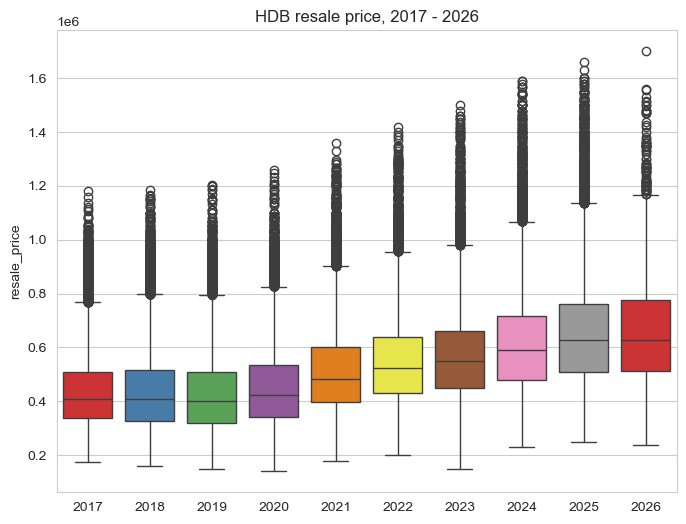

In [33]:
# HDB resale price over the years
plt.figure(figsize=(8,6), dpi=100)
sns.boxplot(data= df_raw, x='Year' ,y='resale_price', palette='Set1')
plt.title("HDB resale price, 2017 - 2026")
plt.xlabel('')
plt.show()

In [38]:
# Average prices of HDB resale prices over the years, a steep price increase of 13% is noticed from 2020-2021 (Covid-19 period)
pd.DataFrame(df_raw.groupby('Year')['resale_price'].mean())

,resale_price
Year,
2017,443743.443497
2018,441310.438730
2019,432180.067468
2020,452312.739224
2021,511417.393772
2022,549701.067962
2023,571814.760274
2024,612597.981425
2025,652481.552576


In [39]:
# to convert the storey of HDB flat into ordinal scale numeric values
def convert_storey_range(storey_range: str)-> float:
    """
    Converts a storey range string into its average numerical value.

    The function takes a storey range in the format 'XX TO YY', splits it into 2 parts, 
    converts these parts to integers and returns the average of these integers.

    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX To YY'.

    Returns:
        float: The average value of the 2 storeys in the range.

    Example:
        convert_storey_range('07 to 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1]))/2

In [43]:
# apply def function
df_raw['storey_range'] = df_raw['storey_range'].apply(convert_storey_range)

In [44]:
df_raw.columns

Index(['town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'Year', 'Month'],
      dtype='object')

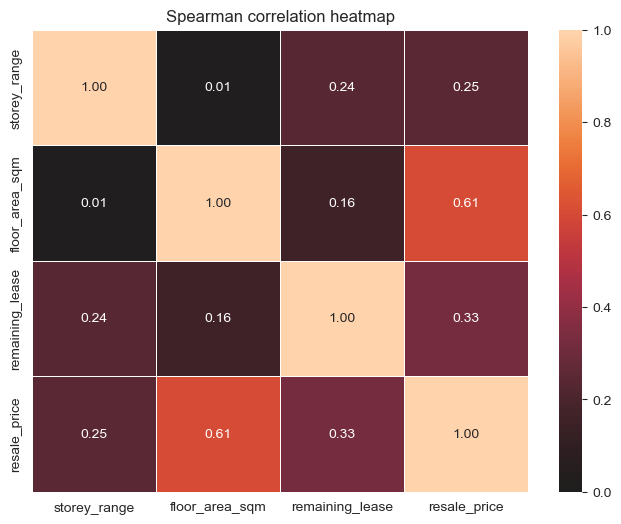

In [54]:
# spearman correlation of numeric values, 'lease_commence_date' not added because it reflects only the year
spearman_vars = df_raw[['storey_range','floor_area_sqm','remaining_lease','resale_price']]

# to compute the Spearman correlation matrix
spearman_corr = spearman_vars.corr(method= 'spearman')

# heatmap: Floor area shows the strongest correlation to price, followed by remaining lease of the flat
plt.figure(figsize=(8,6), dpi=100)
sns.heatmap(spearman_corr, annot=True, center=0, vmin=0, vmax=1, linewidth= 0.5, fmt= '.2f')
plt.title('Spearman correlation heatmap')
plt.show()

In [55]:
# highest floor = 47th level
df_raw['storey_range'].unique()

array([11.,  2.,  5.,  8., 14., 20., 23., 17., 35., 29., 38., 50., 26.,
       41., 32., 47., 44.])

In [56]:
# EDA on year: 2025
df2 = df_raw[df_raw['Year']==2025]

In [57]:
df2.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,Year,Month
196982,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,5.0,44.0,Improved,1979,53.08,340000.0,2025,5
196983,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,8.0,44.0,Improved,1979,52.83,353000.0,2025,8
196984,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,11.0,44.0,Improved,1978,52.17,318000.0,2025,1
196985,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,11.0,44.0,Improved,1978,51.92,338000.0,2025,3
196986,ANG MO KIO,3 ROOM,308A,ANG MO KIO AVE 1,14.0,70.0,Model A,2012,86.00,625000.0,2025,9


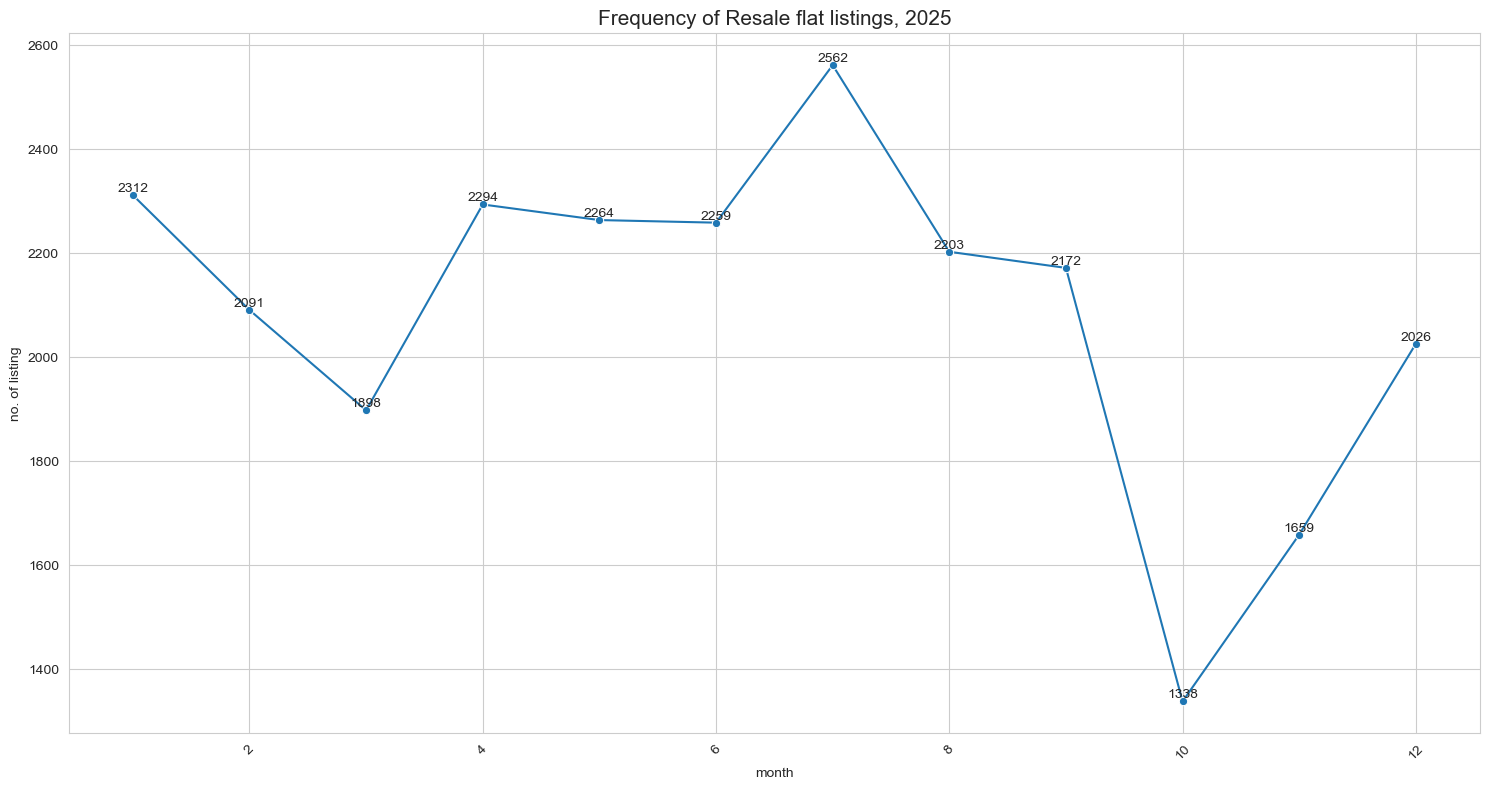

In [62]:
# to view the count of listings per month in 2025
month_counts = df2['Month'].value_counts().sort_index()

# to create a line chart
plt.figure(figsize=(15,8), dpi=100)
sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o')

# to annotate the data points
for x, y in zip(month_counts.index, month_counts.values):
    plt.text(x, y , f'{y}', ha='center', va='bottom')

# July 2025 saw the highest number of resale flats listed, Oct 2025: lowest no. of flats listed
# labelling
plt.title("Frequency of Resale flat listings, 2025", fontsize=15)
plt.xlabel('month')
plt.ylabel('no. of listing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\miche\AppData\Local\Temp\ipykernel_13872\4152319635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='flat_type', y='resale_price', palette='bright')


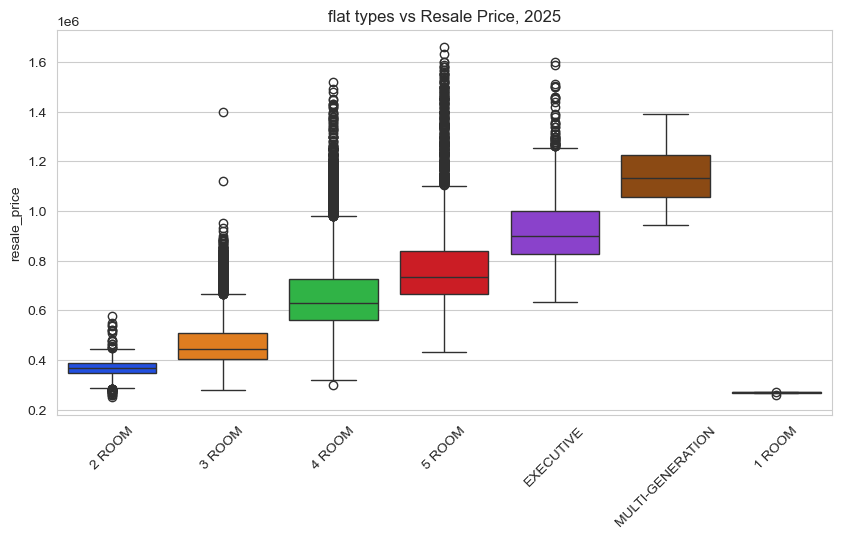

In [65]:
# Flat types vs Price: 2025, Multi-generation flats cost the most most likely due to floor area
plt.figure(figsize=(10, 5), dpi=100)
sns.boxplot(data=df2, x='flat_type', y='resale_price', palette='bright')
plt.title('flat types vs Resale Price, 2025')
plt.xlabel('')
plt.xticks(rotation=45)
plt.show()

C:\Users\miche\AppData\Local\Temp\ipykernel_13872\2444785190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  count_plot = sns.countplot(data=df2, y='town', order=sorted_town_id, palette='Spectral')


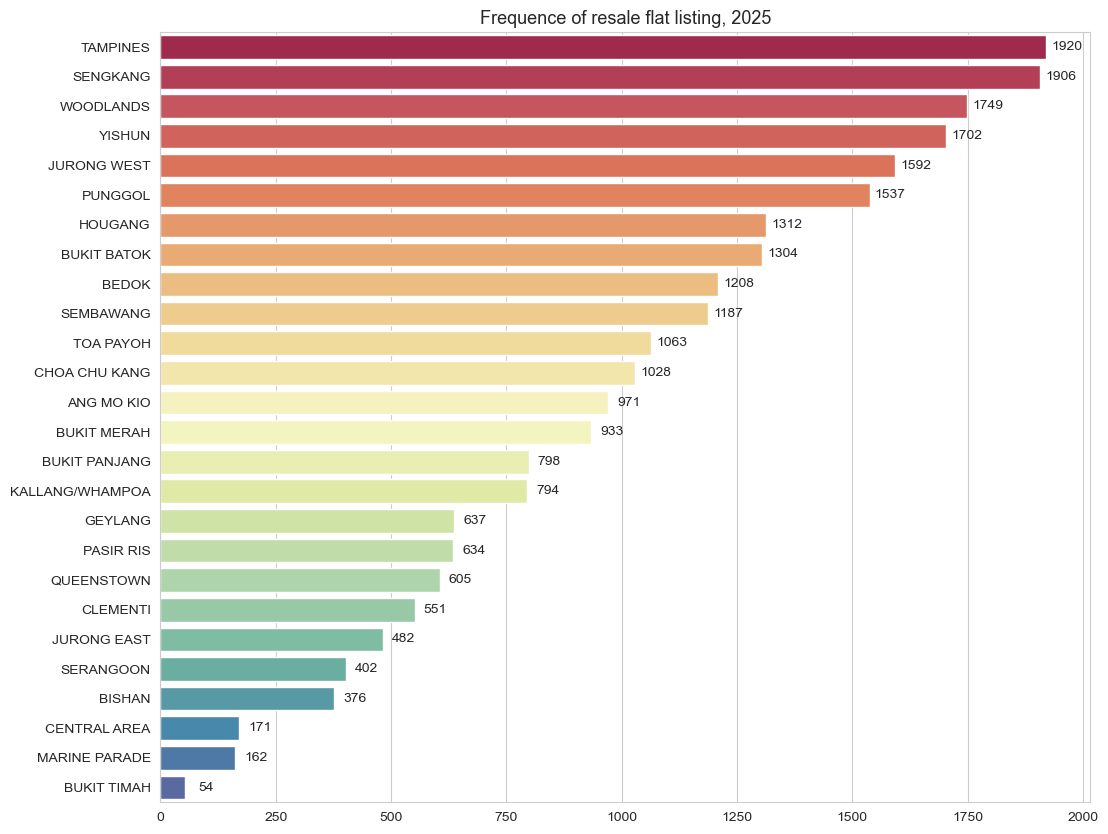

In [70]:
# town name by listing
sorted_town_id = df2['town'].value_counts().index

# Tampinese region saw the highest count of resale flat listed, 2025
# countplot
plt.figure(figsize=(12,10), dpi=100)
count_plot = sns.countplot(data=df2, y='town', order=sorted_town_id, palette='Spectral')
plt.title('Frequence of resale flat listing, 2025', fontsize=13)
plt.ylabel('')
plt.xlabel('')

# to annotate the bars
for p in count_plot.patches:
    count_plot.annotate(format(p.get_width(), '.0f'),
                       (p.get_width(), p.get_y() + p.get_height() /2),
                       ha='center', va='center',
                       xytext = (15, 0),
                       textcoords = 'offset points')
plt.show()

In [72]:
# correlation of all numeric values
df2.select_dtypes(['int','float']).corr()['resale_price'].sort_values(ascending=False)

resale_price           1.000000
floor_area_sqm         0.657611
lease_commence_date    0.389922
remaining_lease        0.389808
storey_range           0.372868
Month                  0.025944
Year                        NaN
Name: resale_price, dtype: float64

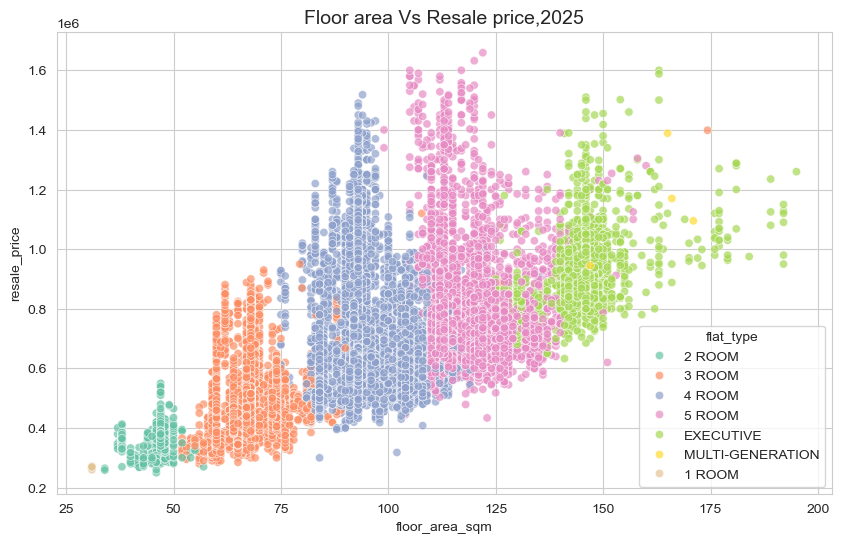

In [80]:
plt.figure(figsize=(10,6), dpi=100)
sns.scatterplot(data=df2, x='floor_area_sqm', y='resale_price', hue='flat_type', palette='Set2', alpha=0.7)
plt.title('Floor area Vs Resale price,2025', fontsize=14)
plt.legend(title='flat_type', loc='lower right')
plt.show()

C:\Users\miche\AppData\Local\Temp\ipykernel_13872\2447295572.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df2, y='town', x='resale_price', palette='bright', ci=None)
C:\Users\miche\AppData\Local\Temp\ipykernel_13872\2447295572.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, y='town', x='resale_price', palette='bright', ci=None)


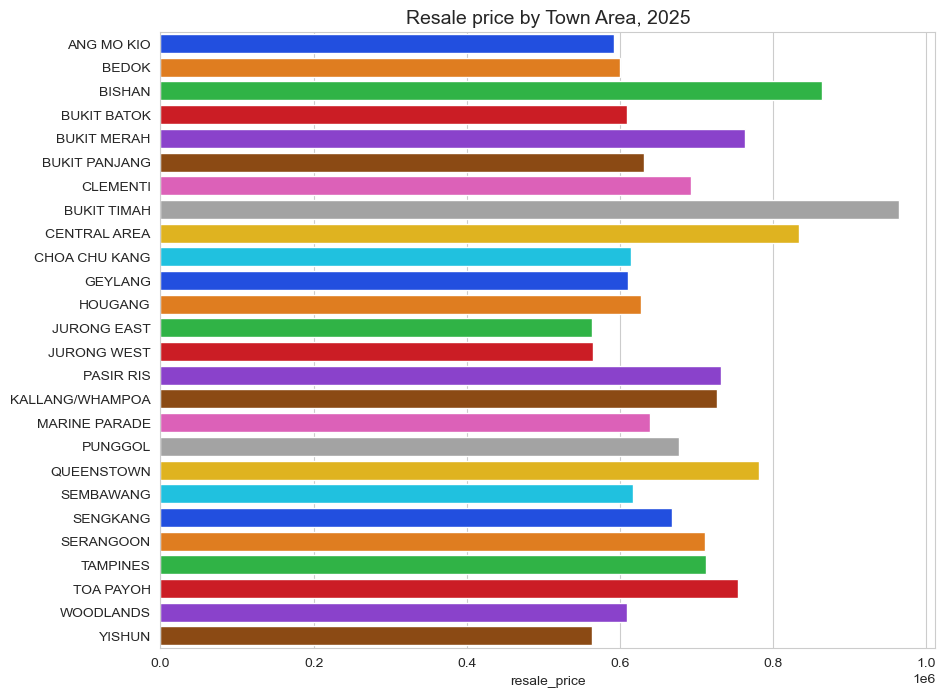

In [84]:
plt.figure(figsize=(10,8), dpi=100)
sns.barplot(data=df2, y='town', x='resale_price', palette='bright', ci=None)
plt.title("Resale price by Town Area, 2025", fontsize=14)
plt.ylabel("")
plt.show()

In [90]:
# Average resale priceing by Town area: Flats around Bt.Timah region cost the most, while Yishun region the least
pd.DataFrame(df2.groupby('town')['resale_price'].mean().sort_values(ascending=False))

,resale_price
town,
BUKIT TIMAH,963642.000000
BISHAN,864040.521277
CENTRAL AREA,834196.824561
QUEENSTOWN,780897.616331
BUKIT MERAH,763247.357985
TOA PAYOH,754140.978363
PASIR RIS,731195.849968
KALLANG/WHAMPOA,726761.594458
TAMPINES,712393.491083


In [95]:
# Median price by flat model: Type S2 & Type S1 the costlist among all
pd.DataFrame(df2.groupby('flat_model')['resale_price'].median().sort_values(ascending=False))

,resale_price
flat_model,
Type S2,1549000.0
Type S1,1370000.0
Premium Apartment Loft,1247500.0
Multi Generation,1132500.0
Premium Maisonette,1025000.0
Improved-Maisonette,1010000.0
Model A-Maisonette,990000.0
DBSS,950000.0
Maisonette,950000.0


In [96]:
# Standard refers to BTO classification, with effect from Oct 2024
# Standard flats come with significant market discounts that are applied to all BTO flats. 
# They form the largest category of BTO flats to be launched every year.

In [125]:
# EDA: resale flat price by Region
df3 = df2[df2['town']=='JURONG EAST']

In [126]:
# average resale price by Flat type, Jurong East 2025
print("Resale HDB price, Jurong East")
pd.DataFrame(df3.groupby('flat_type')['resale_price'].mean().sort_values(ascending=False))

Resale HDB price, Jurong East


,resale_price
flat_type,
EXECUTIVE,939672.357143
5 ROOM,697408.990196
4 ROOM,560543.194444
3 ROOM,418621.868132
2 ROOM,349064.666667


In [127]:
df4 = df2[df2['town']=='CENTRAL AREA']

In [128]:
print("Resale HDB price, Central Area")
pd.DataFrame(df4.groupby('flat_type')['resale_price'].mean().sort_values(ascending=False))

Resale HDB price, Central Area


,resale_price
flat_type,
5 ROOM,1.362144e+06
4 ROOM,1.078795e+06
3 ROOM,5.268168e+05
2 ROOM,3.589109e+05


In [129]:
df6 = df2[df2['town']=='MARINE PARADE']

In [130]:
print("Resale HDB price, Marine Parade")
pd.DataFrame(df6.groupby('flat_type')['resale_price'].mean().sort_values(ascending=False))

Resale HDB price, Marine Parade


,resale_price
flat_type,
5 ROOM,965441.682927
4 ROOM,653619.454545
3 ROOM,485672.325581
2 ROOM,334000.000000


In [131]:
df7 = df2[df2['town']=='JURONG WEST']

In [132]:
print("Resale HDB price, Jurong West")
pd.DataFrame(df8.groupby('flat_type')['resale_price'].median().sort_values(ascending=False))

Resale HDB price, Jurong West


,resale_price
flat_type,
EXECUTIVE,795000.0
5 ROOM,640000.0
4 ROOM,545000.0
3 ROOM,395000.0
2 ROOM,356500.0


In [133]:
df8 = df2[df2['town']=='BUKIT BATOK']

In [136]:
print("Resale HDB price, Bukit Batok")
pd.DataFrame(df8.groupby('flat_type')['resale_price'].median().sort_values(ascending=False))

Resale HDB price, Bukit Batok


,resale_price
flat_type,
EXECUTIVE,869444.0
5 ROOM,810000.0
4 ROOM,623500.0
3 ROOM,420000.0
2 ROOM,375000.0


In [138]:
df_raw.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,Year,Month
0,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,11.0,44.0,Improved,1979,61.33,232000.0,2017,1
1,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,2.0,67.0,New Generation,1978,60.58,250000.0,2017,1
2,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,2.0,67.0,New Generation,1980,62.42,262000.0,2017,1
3,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,5.0,68.0,New Generation,1980,62.08,265000.0,2017,1
4,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,2.0,67.0,New Generation,1980,62.42,265000.0,2017,1
